# JumpSafe Continuation: Setup and Environment Validation

This notebook verifies that the project environment is working correctly, confirms access to the dataset folders, and performs initial data exploration for the JumpSafe continuation project.

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Define Project Paths

In [2]:
project_root = Path("..").resolve()
data_dir = project_root / "data"
raw_dir = data_dir / "raw"
interim_dir = data_dir / "interim"
processed_dir = data_dir / "processed"
sample_dir = data_dir / "sample_videos"

print("Project root:", project_root)
print("Data directory exists:", data_dir.exists())
print("Raw directory exists:", raw_dir.exists())
print("Interim directory exists:", interim_dir.exists())
print("Processed directory exists:", processed_dir.exists())
print("Sample videos directory exists:", sample_dir.exists())

Project root: /Users/arjunrammohandas/Desktop/JumpSafe_Continuation
Data directory exists: True
Raw directory exists: True
Interim directory exists: True
Processed directory exists: True
Sample videos directory exists: True


## 2. Inspect Available Files

In [3]:
raw_files = [
    f for f in raw_dir.iterdir()
    if f.is_file() and not f.name.startswith(".")
]

sample_files = [
    f for f in sample_dir.iterdir()
    if f.is_file() and not f.name.startswith(".")
]

print(f"Files in raw/: {len(raw_files)}")
print(f"Files in sample_videos/: {len(sample_files)}")

print("\nSample files:")
for f in sample_files[:10]:
    print("-", f.name)

Files in raw/: 30
Files in sample_videos/: 2

Sample files:
- good_jump_01.mov
- bad_jump_01.MOV


## 3. Create Basic Metadata Table

In [4]:
all_files = sample_files if len(sample_files) > 0 else raw_files

metadata = pd.DataFrame({
    "filename": [f.name for f in all_files]
})

def infer_label(filename):
    name = filename.lower()
    if "good" in name:
        return "good"
    elif "bad" in name:
        return "bad"
    else:
        return "unknown"

metadata["label_guess"] = metadata["filename"].apply(infer_label)

metadata.head()

,filename,label_guess
0,good_jump_01.mov,good
1,bad_jump_01.MOV,bad


## 4. Early Data Exploration

In [5]:
label_counts = metadata["label_guess"].value_counts()
print(label_counts)

label_guess
good    1
bad     1
Name: count, dtype: int64


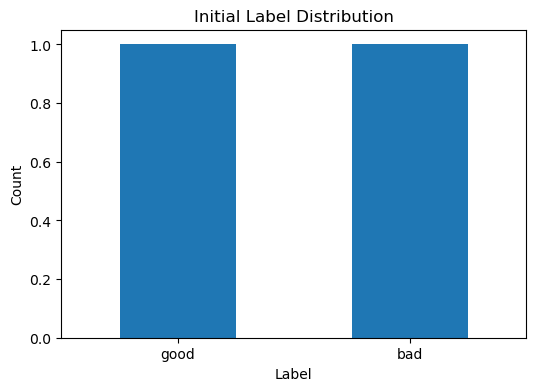

In [6]:
plt.figure(figsize=(6,4))
label_counts.plot(kind="bar")
plt.title("Initial Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

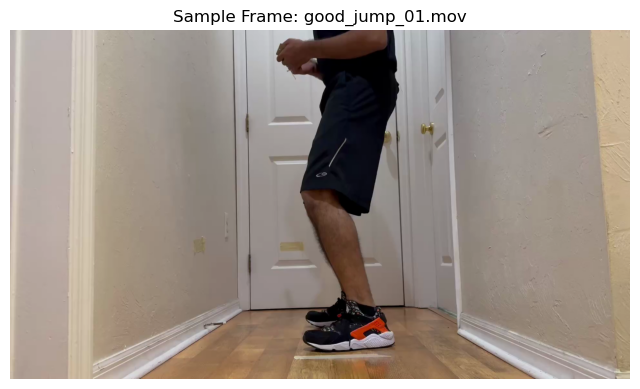

In [7]:
import cv2

sample_video_path = sample_files[0]
cap = cv2.VideoCapture(str(sample_video_path))

success, frame = cap.read()
cap.release()

if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(frame_rgb)
    plt.title(f"Sample Frame: {sample_video_path.name}")
    plt.axis("off")
    plt.show()
else:
    print("Could not read frame from sample video.")

## 5. Environment Verification

In [8]:
print("Setup notebook completed successfully.")
print("Environment is ready for pose extraction and feature engineering.")

Setup notebook completed successfully.
Environment is ready for pose extraction and feature engineering.


## Next Steps
The next development phase will focus on clip-level pose sequence construction, temporal modeling with an LSTM or GRU, and evaluation using leave-one-out cross-validation or stratified k-fold cross-validation at the clip level.